# Aviation Risk Analysis


##  Introduction
Aviation risk analysis quantifies safety and operational risks to support investment decisions. For an investor considering entry into the aviation sector (airline, regional operator, leasing/maintenance business, airport infrastructure, or aggregator), sound analysis must combine data cleaning, exploratory data analysis (to surface patterns and root causes), statistical modelling (to quantify factors that raise or lower risk), and business-context recommendations (commercial, regulatory, insurance, and safety controls).

This project will

- Clean and validate the accident/incident dataset (from Kaggle) you provided.
- Explore and model underlying causes and risk drivers (phase-of-flight, weather, location, aircraft type, operator, time trends).
- Provide concrete recommendations targeted to a company planning to invest in aviation.

# 1.0 Business Understanding
## 1.1 Overview of the Aviation 
The aviation industry provides passenger transport, cargo movement, aircraft operations, maintenance services, and airport infrastructure. It is a globally connected sector that supports trade, tourism, logistics, and economic mobility. Despite being safety-sensitive and highly regulated, aviation remains an essential industry with consistent long-term demand.

Why a Company Would Invest in Aviation         
**Growing demand**  Passenger travel and air cargo continue to expand globally, supported by rising incomes and increased cross-border movement.                
**Multiple investment options** Airlines, aircraft leasing, cargo operations, airport infrastructure, and maintenance (MRO) all offer distinct revenue models.              
**High entry barriers** Regulation, capital requirements, and operational expertise reduce competition and create stable market positions for established players.                    
**Technological improvements** Modern aircraft, automation, and digital maintenance systems reduce operating costs and enhance safety.                 
**Strategic importance** Aviation enables economic activity and often benefits from government support through partnerships or incentives.
               
These factors make aviation attractive for investors seeking long-term returns, diversification, and exposure to essential global infrastructure, provided safety risks are well understood.

## 1.2 Main   Objetive
Use historical aviation accident data to identify key risk drivers and generate clear, evidence-based recommendations for a company considering investment in the aviation sector.

## 1.3 Specific objectives
- Clean and prepare the dataset for accurate analysis. 
- Identify trends and patterns in accidents and fatalities.
- Determine which operational and environmental factors contribute most to aviation risk.
- Quantify risks to highlight safer and riskier aviation segments.
- Provide actionable recommendations that guide investment decisions.

## 1.4 Stakeholders
- Investors and company executives
- Risk and compliance teams
- Aviation operations and safety experts
- Regulators and insurers

## 1.5 Success Criteria
- A clean, reliable dataset with well-defined variables
- Clear ranking of major risk factors
- Accurate analysis supported by measurable indicators
- Recommendations that directly inform investment decisions


# 2.0 Data Understanding
## 2.1 Dataset Overview
- Total Records: 88,889
- Total Variables: 31
- Time Span: Multiple decades of global aviation accident/incident data
- Source: Kaggle – Aviation Accident Database

The dataset contains event identifiers, aircraft details, operational context, injury outcomes, and investigative information. It is extensive enough to identify historical patterns, risk drivers, and operational conditions linked to aviation safety.

## 2.2 Key Variable Categories
**Event Information**
Event.Id, Accident.Number, Event.Date, Location, Country, Report.Status, Publication.Date
**Operational Context**
Investigation.Type, Airport.Code, Airport.Name, FAR.Description, Purpose.of.flight, Weather.Condition, Broad.phase.of.flight
**Aircraft Information**
Make, Model, Registration.Number, Number.of.Engines, Engine.Type, Aircraft.damage, Aircraft.Category
**Injury Outcomes**
Injury.Severity, Total.Fatal.Injuries, Total.Serious.Injuries, Total.Minor.Injuries, Total.Uninjured
**Geolocation**
Latitude, Longitude

These variables among others, enable analysis of when, where, and why accidents occur, and which factors most influence severity.


To have a clearer understanding we start by importing the libraries, load the dataset and inspect it at depth to uncover all the hidden aspects that cannot be seen on the surface.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100000)
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading the dataset and asinging it to data then displaying the head
data=pd.read_csv("aviation_dataset/AviationData.csv",encoding='latin-1',low_memory=False)

data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


#### 2.2.1 Understanding the dataset in depth

In [3]:
#inspecting
data.shape

(88889, 31)

The Dataset has 88,889 recods each has 31 entries

In [4]:
#exploring the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [5]:
# Previewing the columns in the dataset
data.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [6]:
# Previewing datatypes
data.dtypes

Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object
Report.Status 

## 2.3 Sanity Check

In [7]:
data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [8]:
#droping columns not so helpful in my analysis and with huge missing amounts of values - identifying them
columns_to_drop=['Event.Id',
                'Accident.Number',
                'Registration.Number',
                'Latitude',
                'Longitude',
                'Airport.Code',
                'Airport.Name',
                'Report.Status',
                'Publication.Date']

In [9]:
data = data.drop(columns=columns_to_drop, axis=1)

In [10]:
# Converting event data to data
data['Event.Date'] = pd.to_datetime(data['Event.Date'])

In [11]:
# Renaming the columns for easier analysis and visualization
rename_cols = {
    "Investigation.Type": "investigation_type",
    "Event.Date": "event_date",
    "Location": "location",
    "Country": "country",
    "Injury.Severity": "injury_severity",
    "Aircraft.damage": "aircraft_damage",
    "Aircraft.Category": "aircraft_category",
    "Make": "make",
    "Model": "model",
    "Amateur.Built": "amateur_built",
    "Number.of.Engines": "num_engines",
    "Engine.Type": "engine_type",
    "FAR.Description": "far_description",
    "Schedule": "schedule",
    "Purpose.of.flight": "purpose_of_flight",
    "Air.carrier": "air_carrier",
    "Total.Fatal.Injuries": "fatal_injuries",
    "Total.Serious.Injuries": "serious_injuries",
    "Total.Minor.Injuries": "minor_injuries",
    "Total.Uninjured": "uninjured",
    "Weather.Condition": "weather_condition",
    "Broad.phase.of.flight": "phase_of_flight"
}


In [12]:
data = data.rename(columns=rename_cols)

In [13]:
# Checking for duplication of records
data.loc[data.duplicated()]

,investigation_type,event_date,location,country,injury_severity,aircraft_damage,aircraft_category,make,model,amateur_built,num_engines,engine_type,far_description,schedule,purpose_of_flight,air_carrier,fatal_injuries,serious_injuries,minor_injuries,uninjured,weather_condition,phase_of_flight
1371,Accident,1982-05-28,"EVANSVILLE, IN",United States,Non-Fatal,Substantial,Airplane,Cessna,172,No,1.0,Reciprocating,Part 91: General Aviation,NaN,Personal,NaN,0.0,0.0,0.0,7.0,VMC,Cruise
4761,Accident,1983-05-22,"BRIDGEPORT, CA",United States,Fatal(1),Substantial,NaN,Schempp-hirth,STANDARD CIRRUS,No,NaN,Unknown,NaN,NaN,Unknown,NaN,1.0,0.0,0.0,1.0,VMC,Cruise
7941,Accident,1984-04-13,"DELAND, FL",United States,Non-Fatal,Substantial,NaN,Cessna,172P,No,1.0,Reciprocating,NaN,NaN,Instructional,NaN,0.0,0.0,0.0,2.0,VMC,Taxi
8661,Accident,1984-06-18,"PORTLAND, AR",United States,Non-Fatal,Substantial,NaN,Snow,AT400,No,1.0,Turbo Prop,NaN,UNK,Aerial Application,NaN,0.0,0.0,0.0,2.0,VMC,Landing
19820,Incident,1988-03-10,"GREENSBORO, NC",United States,Incident,NaN,NaN,Boeing,737,No,2.0,Turbo Fan,NaN,SCHD,Unknown,Continental Airlines (dba: Texas Int'l Airline...,0.0,0.0,0.0,159.0,VMC,Maneuvering
21077,Incident,1988-08-05,"ATLANTA, GA",United States,Incident,Minor,NaN,Douglas,DC-9-51,No,2.0,Turbo Fan,NaN,SCHD,Unknown,NaN,0.0,0.0,0.0,199.0,UNK,Taxi
24878,Accident,1990-02-09,"TETERBORO, NJ",United States,Non-Fatal,Substantial,NaN,Mitsubishi,MU-2B-35,No,2.0,Turbo Prop,NaN,NSCH,Unknown,Epps Air Service,0.0,0.0,0.0,2.0,VMC,Taxi
26868,Accident,1990-10-20,"KENT, OH",United States,Non-Fatal,Substantial,NaN,Cessna,152,No,1.0,Reciprocating,NaN,NaN,Instructional,NaN,0.0,0.0,0.0,2.0,VMC,Approach
27496,Accident,1991-03-02,"MARANA, AZ",United States,Non-Fatal,Substantial,NaN,Boeing,A75,No,1.0,Reciprocating,NaN,NaN,Other Work Use,NaN,0.0,0.0,0.0,3.0,VMC,Maneuvering
27811,Accident,1991-04-19,"SANTA ROSA, NM",United States,Non-Fatal,Substantial,NaN,Ercoupe (eng & Research Corp.),415-C,Yes,1.0,Reciprocating,NaN,NaN,Personal,NaN,0.0,0.0,1.0,1.0,VMC,Climb


In [14]:
#data.loc[data.duplicated(subset=['investigation_type','event_date'])]

The result above are not exact identical so we wont be droping them.

In [15]:
# Checking duplicated subsets
# data.query('Model == "172"')
# if duplicated we can try and revesrse it by data = data.loc[~data.duplicated(subset=['Model'])].reset_index(drop=True).copy()

In [16]:
#checking for missing values
data.isna().sum()

investigation_type        0
event_date                0
location                 52
country                 226
injury_severity        1000
aircraft_damage        3194
aircraft_category     56602
make                     63
model                    92
amateur_built           102
num_engines            6084
engine_type            7096
far_description       56866
schedule              76307
purpose_of_flight      6192
air_carrier           72241
fatal_injuries        11401
serious_injuries      12510
minor_injuries        11933
uninjured              5912
weather_condition      4492
phase_of_flight       27165
dtype: int64

In [17]:
#checking for the % of misssing data
data.isna().mean()*100

investigation_type     0.000000
event_date             0.000000
location               0.058500
country                0.254250
injury_severity        1.124999
aircraft_damage        3.593246
aircraft_category     63.677170
make                   0.070875
model                  0.103500
amateur_built          0.114750
num_engines            6.844491
engine_type            7.982990
far_description       63.974170
schedule              85.845268
purpose_of_flight      6.965991
air_carrier           81.271023
fatal_injuries        12.826109
serious_injuries      14.073732
minor_injuries        13.424608
uninjured              6.650992
weather_condition      5.053494
phase_of_flight       30.560587
dtype: float64

In [18]:
# Futher droping columns with high missingness and with low value to the analysis
cols_to_drop = ['air_carrier','schedule','far_description']
data = data.drop(columns=cols_to_drop, axis=1)

In [19]:
# Identifying garbage values
for i in data.select_dtypes(include='object').columns:
    print(data[i].value_counts())
    print("'''"*10)

investigation_type
Accident    85015
Incident     3874
Name: count, dtype: int64
''''''''''''''''''''''''''''''
location
ANCHORAGE, AK                                                      434
MIAMI, FL                                                          200
ALBUQUERQUE, NM                                                    196
HOUSTON, TX                                                        193
CHICAGO, IL                                                        184
FAIRBANKS, AK                                                      174
TUCSON, AZ                                                         142
PHOENIX, AZ                                                        132
ORLANDO, FL                                                        132
ENGLEWOOD, CO                                                      131
SAN DIEGO, CA                                                      119
JACKSONVILLE, FL                                                   119
Anchorage, AK              

### 2.3.1 Feature Understanding
Plotting feature distribution   
Histogram. KDE, baxplot

#### 2.3.1.1 Univariate Analysis

In [20]:
# Data distribution
data.describe()

,event_date,num_engines,fatal_injuries,serious_injuries,minor_injuries,uninjured
count,88889,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1999-09-17 17:13:39.354475904,1.146585,0.647855,0.279881,0.357061,5.325440
min,1948-10-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1989-01-15 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1998-07-18 00:00:00,1.000000,0.000000,0.000000,0.000000,1.000000
75%,2009-07-01 00:00:00,1.000000,0.000000,0.000000,0.000000,2.000000
max,2022-12-29 00:00:00,8.000000,349.000000,161.000000,380.000000,699.000000
std,NaN,0.446510,5.485960,1.544084,2.235625,27.913634


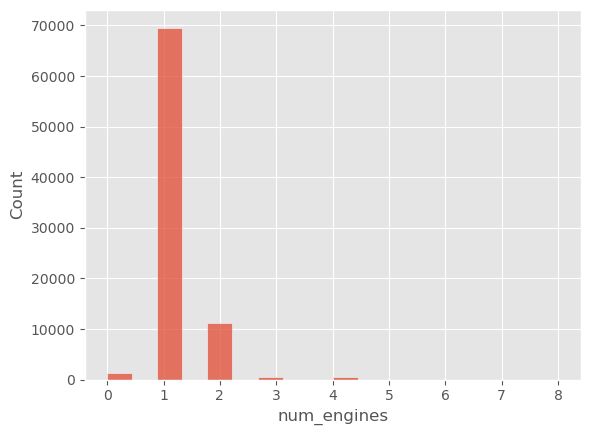

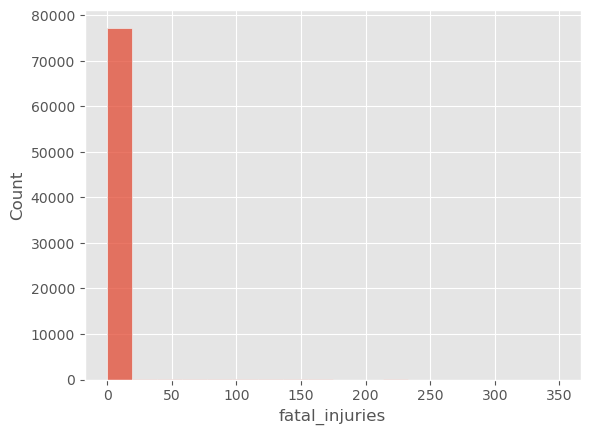

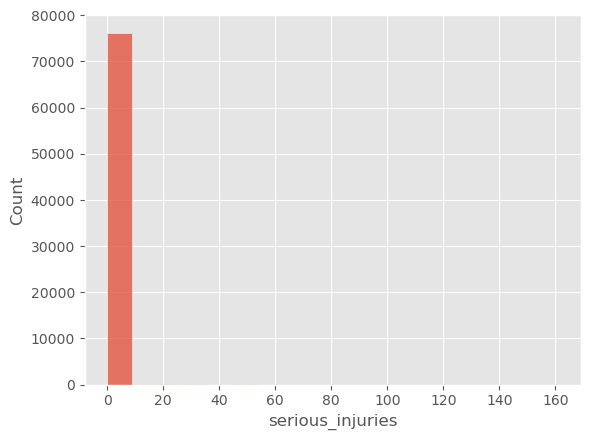

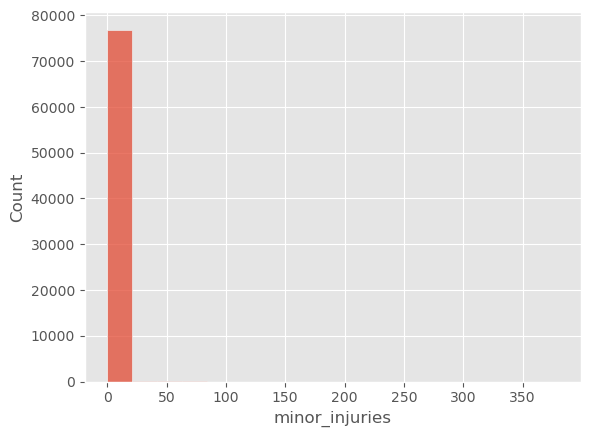

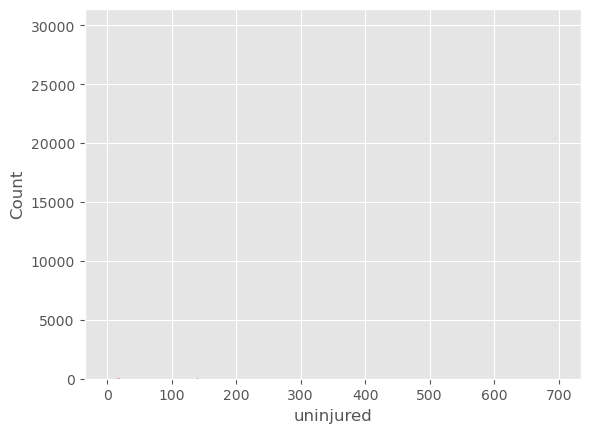

In [21]:
# Data distribution for numeric columns
for i in data.select_dtypes(include='number').columns:
    sns.histplot(data,x=i)
    plt.show()

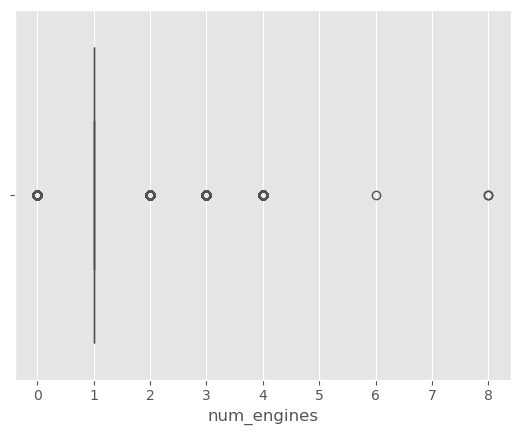

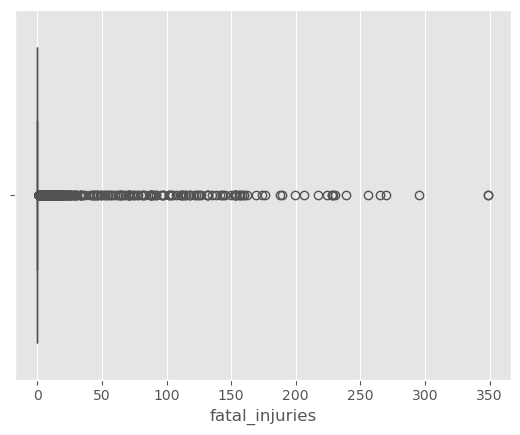

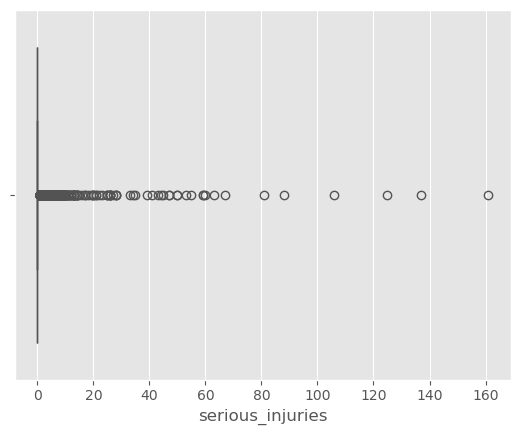

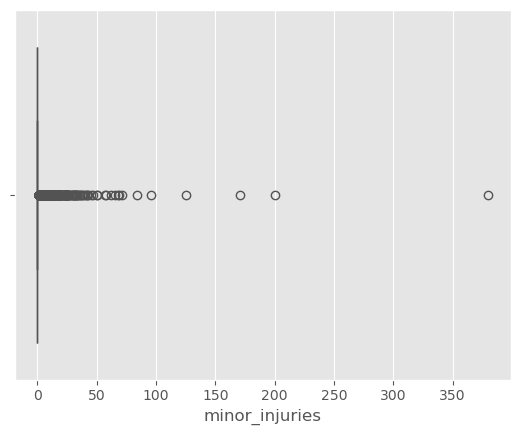

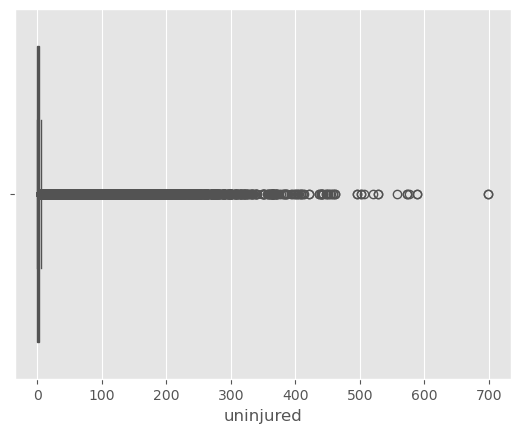

In [24]:
# Boxplot to identify outliers for numerical data
for i in data.select_dtypes(include='number').columns:
    sns.boxplot(data,x=i)
    plt.show()

In [23]:
# Data distribution for categorical columns
data.describe(include='object').T


,count,unique,top,freq
investigation_type,88889,2,Accident,85015
location,88837,27758,"ANCHORAGE, AK",434
country,88663,219,United States,82248
injury_severity,87889,109,Non-Fatal,67357
aircraft_damage,85695,4,Substantial,64148
aircraft_category,32287,15,Airplane,27617
make,88826,8237,Cessna,22227
model,88797,12318,152,2367
amateur_built,88787,2,No,80312
engine_type,81793,12,Reciprocating,69530


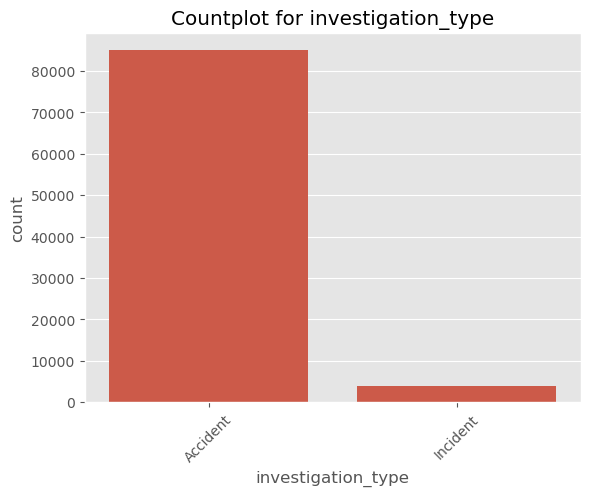

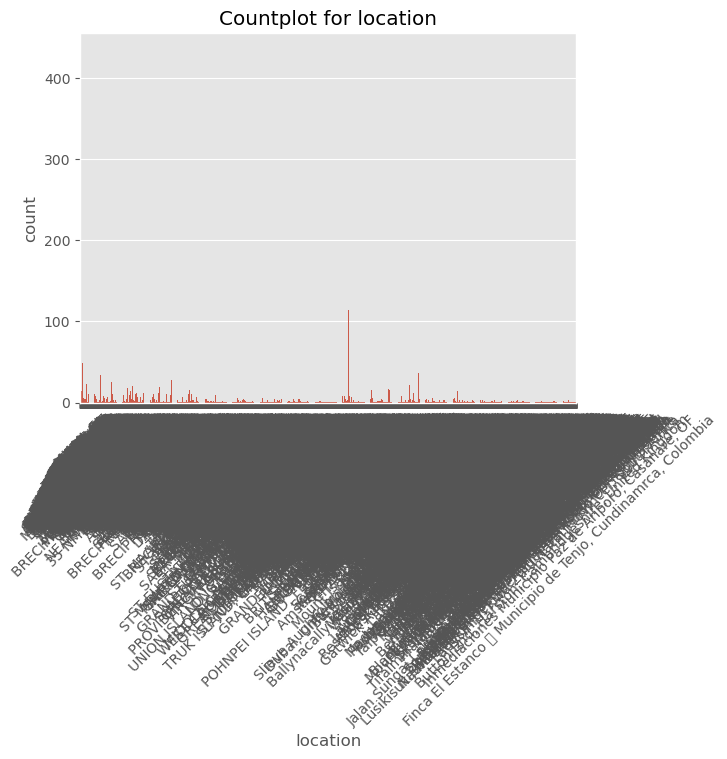

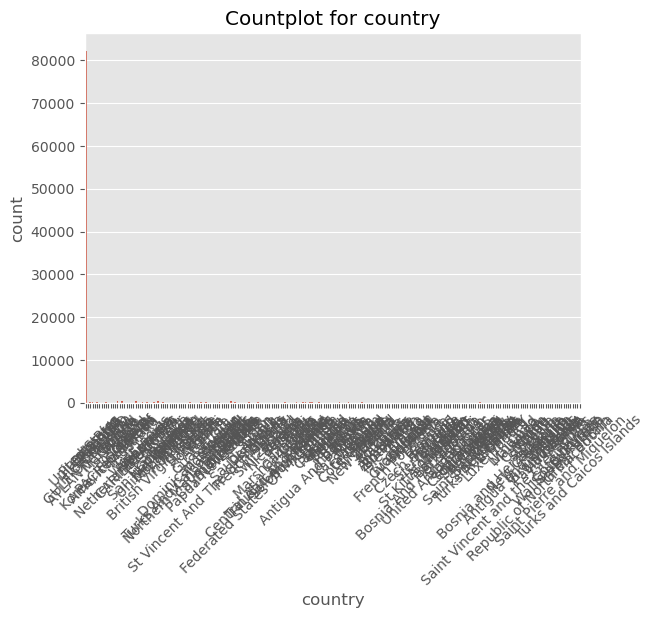

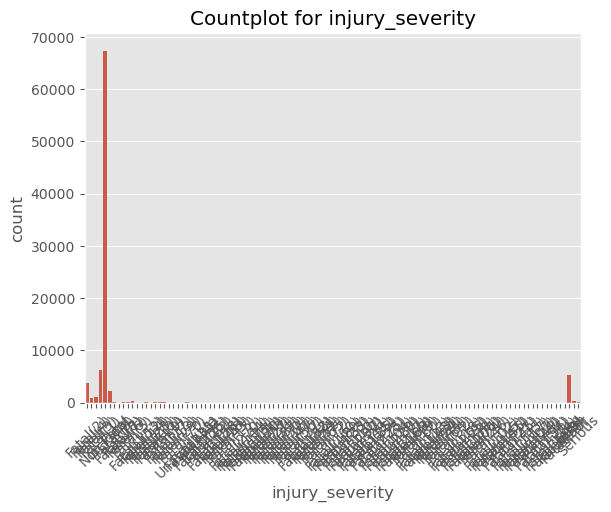

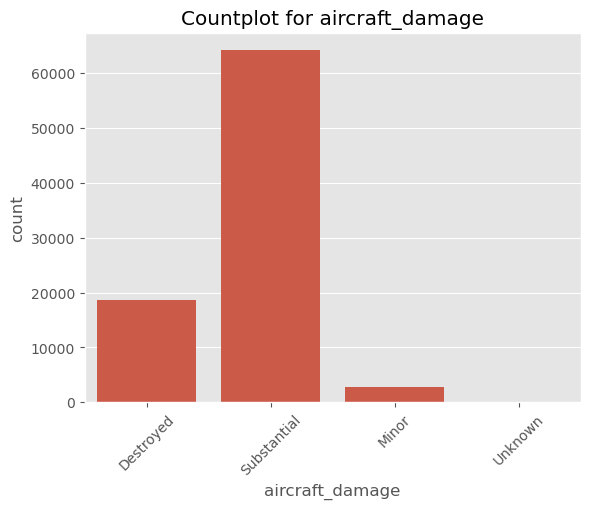

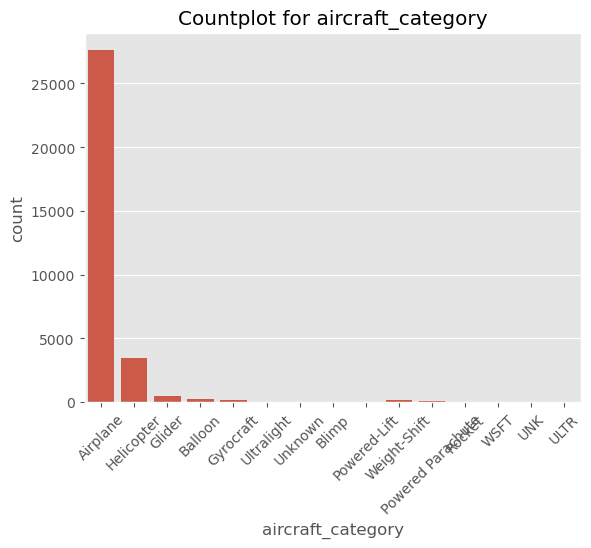

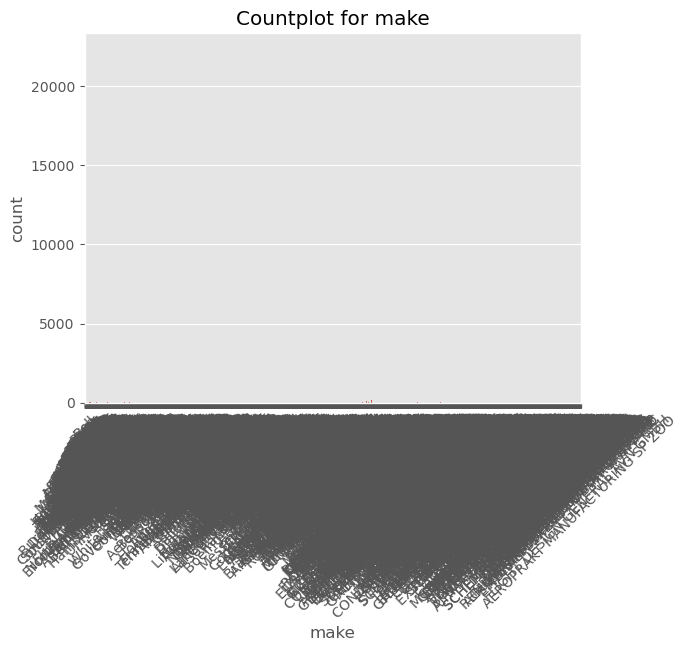

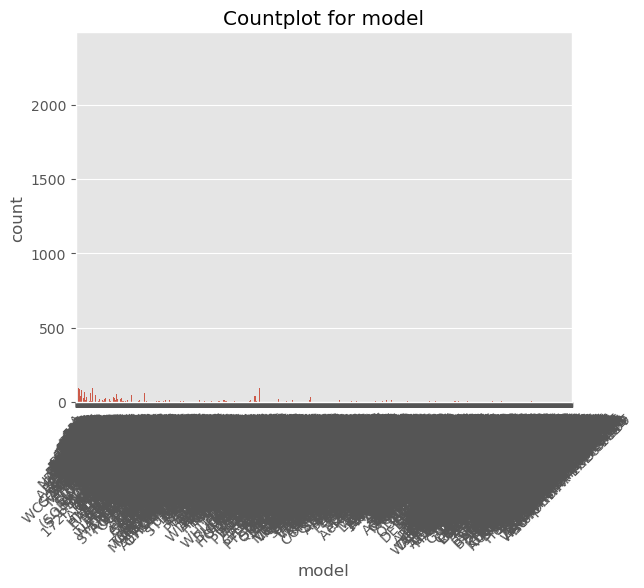

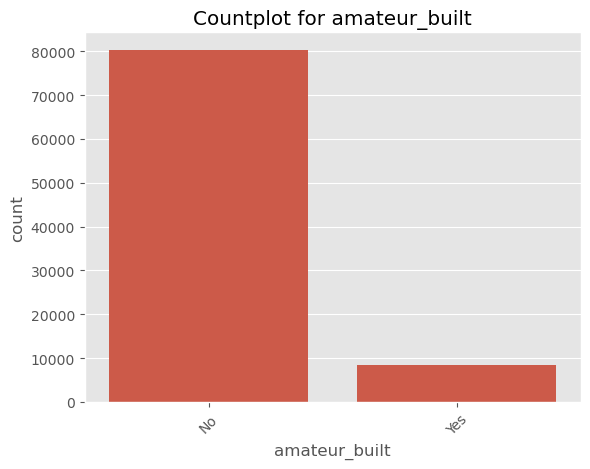

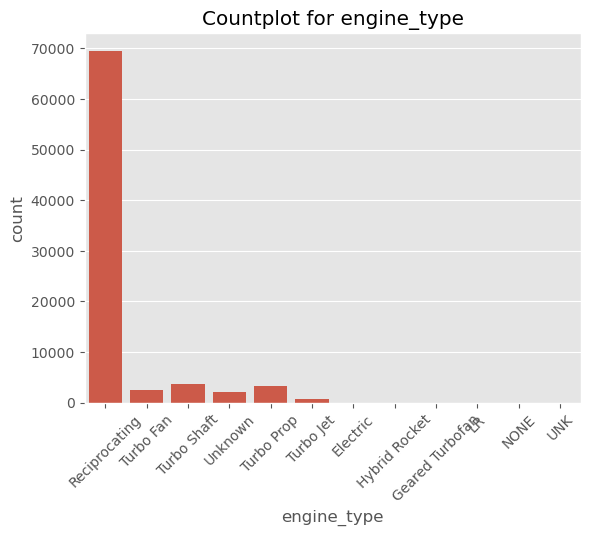

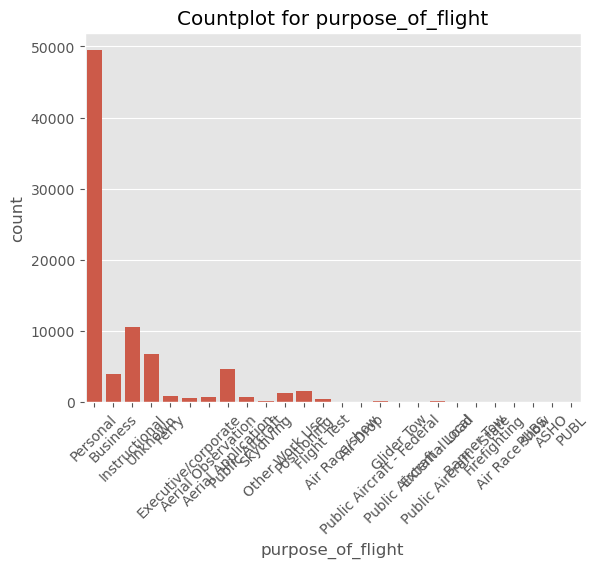

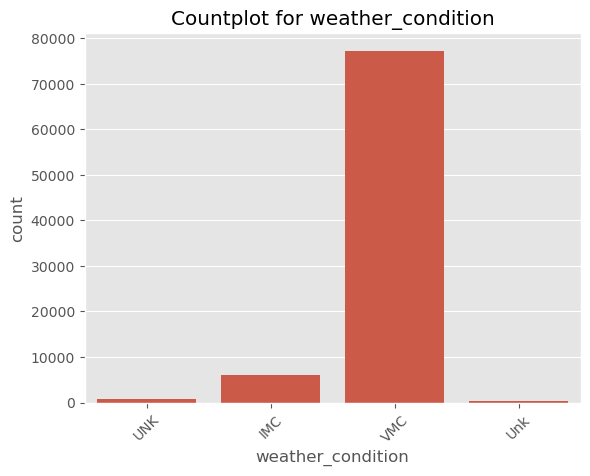

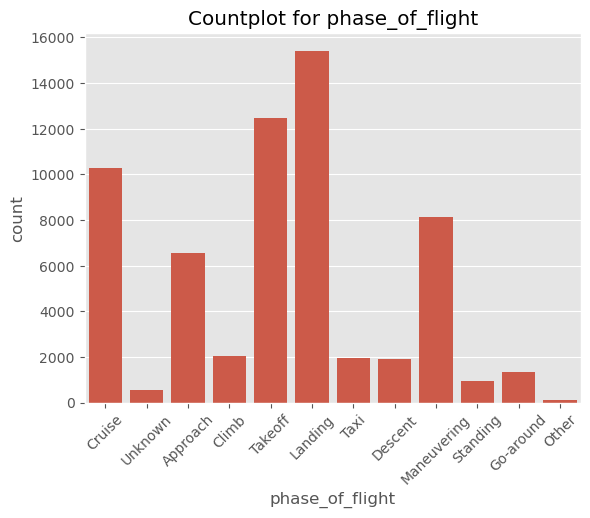

In [25]:
# Bar plot for the distribution of each column
for col in data.select_dtypes(include='object').columns:
    sns.countplot(data=data, x=col)
    plt.title(f"Countplot for {col}")
    plt.xticks(rotation=45)
    plt.show()

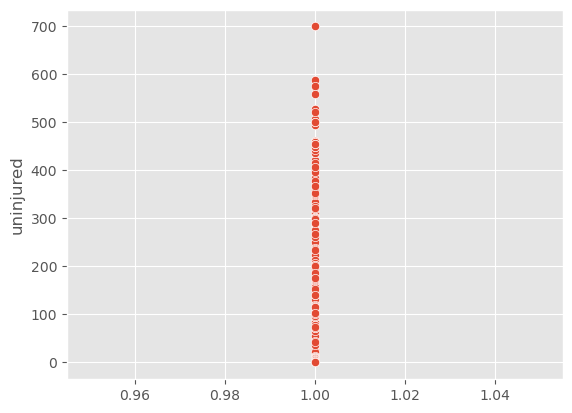

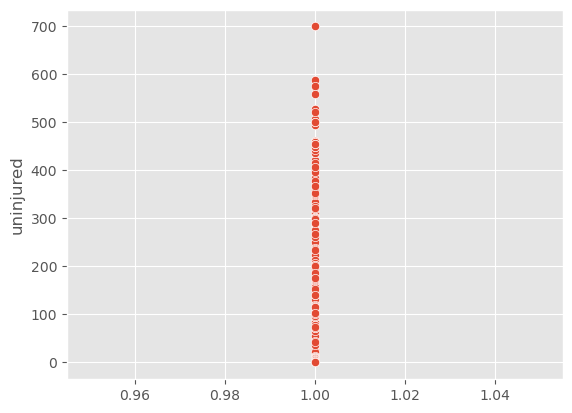

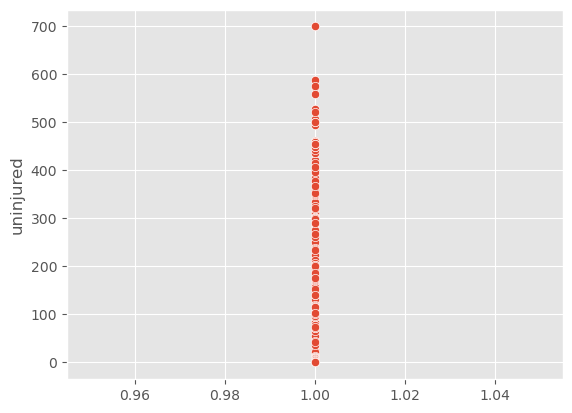

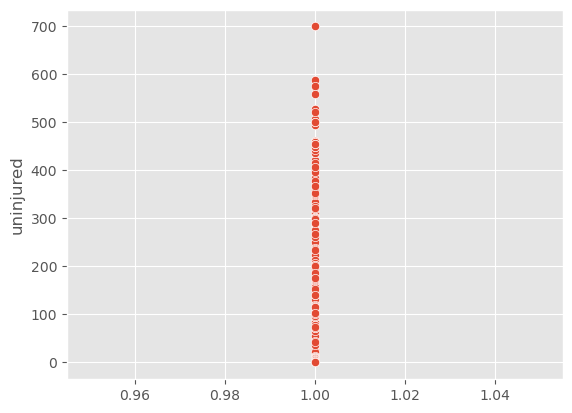

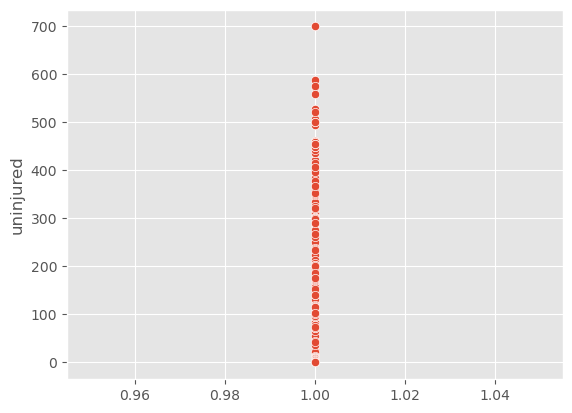

In [26]:
# Scatter plot to understand the relationship
for i in data.select_dtypes(include='number').columns:
    sns.scatterplot(data,x=1, y='uninjured')
    plt.show()

In [ ]:
#filling missing values in numeric columns
data = data.copy()
num_cols = data.select_dtypes(include='number').columns
for col in num_cols:
    if data[col].isna().any():                        
        mode_series = data[col].mode(dropna=True)
        if (not mode_series.empty) and (mode_series.iloc[0]== 0.0):
            fill_val =data[col].mean(skipna=True)     
        else:
            fill_val =data[col].median(skipna=True)
        data[col].fillna(fill_val,inplace=True)

In [ ]:
#filling missing values for the above (Airpoort name & Airport code)
data=data.copy()
valid = data[data['Airport.Code'].notna() & data['Airport.Name'].notna()]
code_to_name = valid.drop_duplicates('Airport.Code').set_index('Airport.Code')['Airport.Name'].to_dict()
name_to_code = valid.drop_duplicates('Airport.Name').set_index('Airport.Name')['Airport.Code'].to_dict()
missing_name = data['Airport.Name'].isna() & data['Airport.Code'].notna()
data.loc[missing_name, 'Airport.Name'] = data.loc[missing_name, 'Airport.Code'].map(code_to_name)
missing_code = data['Airport.Code'].isna() & data['Airport.Name'].notna()
data.loc[missing_code, 'Airport.Code'] = data.loc[missing_code, 'Airport.Name'].map(name_to_code)
data['Airport.Code'].fillna('Unknown Code', inplace=True)
data['Airport.Name'].fillna('Unknown Airport', inplace=True)

My dataset is now clean and set for visualizations. I have decided to keep some of the placeholders as they have valuable information about the data regarding to their respective columns and removing them or replacing them would have rendered my results biased. In other columns i have desided to keep the missing values because they also hold valuable information about those respective columns and removing them or replacing them would have rendered my data inconsistent. Summatively my clean data is as redered from here on.

In [ ]:
#Inspecting data
data.isna().sum()

In [ ]:
#inspecting data
data.info()

In [ ]:
#inspecting
data.columns

In [ ]:
#Inspecting
data.head(2)

In [ ]:
#Exploring data
#Top aircraft makes
data['Make'].value_counts().head(20)


In [ ]:
#Exploring data
#Engine safety comparison  
data.groupby(['Number.of.Engines','Engine.Type'])['Injury.Severity'].value_counts()

In [ ]:
#Fatal vs non-fatal injury by make
data.groupby('Make')['Injury.Severity'].value_counts()

In [ ]:
#Getting makes with significant accident history (30+ incidents)
major_makes = data['Make'].value_counts()
significant_makes = major_makes[major_makes >= 30]
print("Top 20 major makes:")
print(significant_makes.head(20))
major_aircraft_df = data[data['Make'].isin(significant_makes.index)]

Important visualizations from this dataset.

In [ ]:
#Accidents by make 
accident=data['Investigation.Type']=='Accident'
accident_count=data.loc[accident,'Make'].value_counts().rename_axis('Make').reset_index(name='accident_cnt')

In [ ]:
top20=accident_count.head(20)
fig,ax=plt.subplots(figsize=(12,10))
ax.barh(top20['Make'],top20['accident_cnt'])
ax.invert_yaxis()
ax.set_title('Top Aircraft Makes Involed in Accidents')
ax.set_xlabel('Number of accidents since 1962')
ax.set_ylabel('Make')
ax.grid(True)
plt.show()

The chart above shows top twenty makes involved in major accidents reported since 1962. While high counts represent popularity they present areas for deeper dive for analysis.

In [ ]:
#incidents by make analysis
incident=data['Investigation.Type']=='Incident'
incidents=data.loc[incident,'Make'].value_counts().rename_axis('Make').reset_index(name='incident_cnt')
top20=incidents.head(20)
fig,ax=plt.subplots(figsize=(12,10))
ax.barh(top20['Make'],top20['incident_cnt'])
ax.invert_yaxis()
ax.set_title('Top Aircraft Makes Involed in Incidents')
ax.set_xlabel('Number of incidents since 1962')
ax.set_ylabel('Make')
ax.grid(True)
plt.show()

Obs - The chart above shows top twenty makes involved in major incidents reported since 1962. Boeing has the highest number of incidents while Grumman has the lowest counts of incidents.

In [ ]:
#Aircrafts accidents and incidents per year
data['Event.Date'] = pd.to_datetime(data['Event.Date'])
data['Year']=data['Event.Date'].dt.year
events_per_year=data.groupby(['Year','Investigation.Type']).size().unstack(fill_value=0)
fig,ax=plt.subplots(figsize=(10,8))
for event_type in events_per_year.columns:
    ax.plot(events_per_year.index, events_per_year[event_type],marker='o',linewidth=2,label=event_type)
ax.set_xlim(left=1980)
ax.set_title('Aircraft Accidents and Incidents Over Time', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.grid(True)
ax.legend(title='Investigation Type')
plt.show()


The above visual shows how accidents and incidents have happened over the years since 1962.The seem to be reducing gradually over the years.Probably suggesting improvent of the aircrafts over the years. 

In [ ]:
#Assessing number of accidents and incidents by number of engines over time
data['Event.Date'] = pd.to_datetime(data['Event.Date'], errors='coerce')
data['Year'] = data['Event.Date'].dt.year
yearly_engines = (data.groupby(['Year', 'Number.of.Engines']).size().unstack(fill_value=0)      .sort_index()            )
plt.figure(figsize=(14, 8))
palette = plt.cm.get_cmap('tab20c', yearly_engines.shape[1])
colors = [palette(i) for i in range(yearly_engines.shape[1])]
yearly_engines.plot.area(stacked=True,color=colors,alpha=0.8,ax=plt.gca())
plt.title('Aircraft Events by Number of Engines ({}–{})'.format(yearly_engines.index.min(), yearly_engines.index.max()),fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Events (Accidents + Incidents)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(left=yearly_engines.index.min())
plt.legend(title='Number of Engines',frameon=False,ncol=2,title_fontsize=12,fontsize=10)
plt.show()


Its clearly observed one engine has the highest number of accidents while 8 engines is not even visible in our area chart meaning it has very minimal number of accidents. This is suggesting the higher the number of engines the less the likelyhood of accidents to happen.

In [ ]:
#Assessing total fatal injuries by weather condition and engine type
pivot_table = data.pivot_table(index='Weather.Condition',columns='Engine.Type',values='Total.Fatal.Injuries',aggfunc='sum',fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table,annot=True, cmap='bwr_r', linewidths=.5)
plt.title('Heatmap of Total Fatal Injuries by Weather Condition and Engine Type')
plt.xlabel('Engine Type')
plt.ylabel('Weather Condition')
plt.show()

First Unk and UNK from weather condition and engine type respectively represent no record taken. Diving into observation there is a relationship between the type of engine and weather codition. For instance taking the Reciprocating engine it has a high number of accidents during the VMC weather condition an compared to IMC. this shows that different engine type  is affected by different weather conditions while other like the electric and LR are not affected.Also aircrafts with no engines are not affected by weather condition like from above none has no accidents on any weather condition.

In [ ]:
#purpose of flight invovment in accident
purpose_counts = data['Purpose.of.flight'].value_counts().head(20).sort_values()
heatmap_data = pd.DataFrame(purpose_counts).reset_index()
heatmap_data.columns = ['Purpose of Flight', 'Number of Accidents']
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data.set_index('Purpose of Flight').T, cmap='Greens', annot=True, fmt='d')
plt.xlabel('Purpose of Flight')
plt.ylabel('Number of Accidents')
plt.title('Top 20 Purposes of Flight Involved in Accidents')
plt.show()



From the above personal purpose seem to have the highest number of accidents followed by instructional.Unknown are the missing values i had in the dataset had to name them that instead of droping the rows to enhance consistency. Other purposes business included seem to have moderate to few counts of accidents.

In [ ]:
#Assessing aircraft damage by make
top_20_makes = data['Make'].value_counts().head(20).index
filtered_df = data[data['Make'].isin(top_20_makes)]
stacked_data = filtered_df.pivot_table(index='Make',columns='Aircraft.damage',aggfunc='size',fill_value=0)
stacked_data.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.title('Aircraft Damage Severity by Top 20 Makes')
plt.xlabel('Aircraft Make')
plt.ylabel('Number of Incidents')
plt.legend(title='Damage Level')
plt.tight_layout()
plt.show()


From the above it can be observed that CESSNA and PIPER are leading in aircraft damage with CESSNA leading in destroyed,minor, and substantial damages. Other makes seem to have minimal damage cases. 

In [ ]:
#Assessing purpose of flight to Aircraft damage
combo_counts = pd.crosstab(data['Purpose.of.flight'], data['Aircraft.damage'])
combo_counts = combo_counts.loc[combo_counts.sum(axis=1).nlargest(10).index]
dat = combo_counts.stack().reset_index()
dat.columns = ['Purpose', 'Damage', 'Count']
plt.figure(figsize=(12, 10))
for i in range(len(dat)):
    plt.scatter(dat['Damage'][i],dat['Purpose'][i],s=dat['Count'][i]*10,color='violet',alpha=0.6,edgecolors='black')
for i in range(len(dat)):
    plt.text(dat['Damage'][i],dat['Purpose'][i],str(dat['Count'][i]),fontsize=8,ha='center', va='center')
plt.title('Aircraft Damage Severity by Purpose of Flight Top 10')
plt.xlabel('Damage Level')
plt.ylabel('Purpose of Flight')
plt.tight_layout()
plt.show()


Unknown are all the values that were missing choose to ingnore when observing. Its clearly seen that personal purpose is leading in all the damage level, ie. Substantial, Destroyed, and minor damages. The others can be observed clearly also from the above.

In [ ]:
#injury by make and model
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
injury_summary = data.groupby(['Make', 'Model'], as_index=False)[injury_cols].sum()
top_injury_makes = injury_summary.sort_values(by='Total.Fatal.Injuries', ascending=False).head(10)
injury_melted = top_injury_makes.melt(id_vars=['Make', 'Model'],value_vars=injury_cols,var_name='Injury_Type', value_name='Count')
injury_melted['Aircraft'] = injury_melted['Make'] + " - " + injury_melted['Model']
plt.figure(figsize=(12,8))
sns.barplot(data=injury_melted, x='Count', y='Aircraft', hue='Injury_Type')
plt.title('Injury Type Counts by Aircraft Make & Model')
plt.xlabel('Number of Injuries')
plt.ylabel('Aircraft (Make - Model)')
plt.legend(title='Injury Type')
plt.tight_layout()
plt.show()


The observation made above from different models and their specific makes shows the extent of injuries each one of them caused during the accident. From each model the number of total fatal, total serious, total minor, and uninjured injuries can be seen clearly. CESSNA seem to have the highest of all the injuries summing the different models it has.

In [ ]:
#Assessing phase of flight to accidents
phase_counts = data['Broad.phase.of.flight'].value_counts()
plt.figure(figsize=(12, 6))
plt.step(range(len(phase_counts)), phase_counts.values, where='mid', color='indigo', linewidth=2)
plt.scatter(range(len(phase_counts)), phase_counts.values, color='darkorange', s=100)
# Label values
for i, val in enumerate(phase_counts.values):
    plt.text(i, val + 5, str(val), ha='center', fontsize=9)
plt.xticks(ticks=range(len(phase_counts)), labels=phase_counts.index, rotation=45)
plt.xlabel('Phase of Flight')
plt.ylabel('Number of Accidents')
plt.title('Aircraft Accidents by Phase of Flight (Step Plot)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Unknown is all the values that were missing, decided to keep it to enhance consistency in my data. An observation is made, many accidents happen during the landing phase followed by takeoff,cruise,maneuverung,approach while others seem to have moderate accidents.

In [ ]:
# Calculate percentages for each weather condition
cross_tab = pd.crosstab(index=data['Weather.Condition'],columns=data['Investigation.Type'],margins=False ) 
percentage_tab = pd.crosstab(index=data['Weather.Condition'],columns=data['Investigation.Type'],normalize='index'     ) * 100
plt.figure(figsize=(12, 8))
percentage_tab.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Percentage Distribution of Investigation Types by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Percentage (%)')
plt.legend(title='Investigation Type', loc='upper left')
plt.xticks(rotation=45)
plt.show()


The Unk stands for values that were missing so we'll ignore it in our conclusions. UNK were records recoded but not given a specific clasification. Overall VMC seem to cause the higest number of accidents and a few incidents. On the other hand IMC has slightly lower percentage of accidents.

In [ ]:
data['Engine.Type'].unique()

In [ ]:
def clean_engine_type(value):
    value = str(value).strip().title()
    if value in ['UKN']:
        return 'Unknown'
    return value
data['Engine.Type'] = data['Engine.Type'].apply(clean_engine_type)

In [ ]:
#Assessing number of accidents by engine type
engine_counts = data['Engine.Type'].value_counts()
labels = engine_counts.index
values = engine_counts.values
# Converting to radians
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
bars = ax.bar(angles, values, width=0.4, color='darkgreen', alpha=0.7)
ax.set_xticks(angles)
ax.set_xticklabels(labels)
ax.set_yticklabels([])
plt.title('Number of Accidents by Engine Type', y=1.1)
plt.show()


Its clear from the above, Reciprocating engine has the lagest number of accidents followed by Turbo Shaft, and Turbo Prop. The rest have very minimal thats why they are not visible from our poler view.

In [ ]:
#Scatter matrix for all the columns with numeric data
numerical_cols = data.select_dtypes(include=[np.number])
axes = pd.plotting.scatter_matrix(numerical_cols, alpha=0.6,figsize=(15, 12),diagonal='hist', density_kwds={'color': 'blue'},hist_kwds={'bins': 20, 'alpha': 0.7})
plt.suptitle('Scatter Matrix of Numerical Columns', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()


From the visual above we can see how different fields relate to each other.

In [ ]:
data.to_csv('clean_data.csv',index=False,encoding='utf-8-sig')